# Deep Learning

Systems that mimic human brain's ability to learn.

![Deep Learning Models](https://www.artiba.org/Content/Images/types-of-deep-learning-models.jpg)

![](https://media.geeksforgeeks.org/wp-content/uploads/20250703121717652998/1-.webp)

ANN is a computational model inspired by the structure and functional aspects of biological neural networks. It is the cornerstone of Deep Learning.

It consists of large number of simple, highly interconnected processing elements (neurons) working in unison to solve specific problems.

The term "Deep" refers to the number of layers through which the data is transformed. Modern networks have hundreds of layers. Each layer extracts progressively higher level features from the raw input.

* Shallow Layers: Might detect simple edges or colors
* Deep Layers: Might detect complex shapes, textures, or even specific objects.

![](https://media.geeksforgeeks.org/wp-content/uploads/20230410104038/Artificial-Neural-Networks.webp)

Biological Term   |   Artificial Equivalent
* Dendrite:           Input Layer / Incoming Weights
* Cell Body:          Summation and Activation
* Axon:               Output of the Neuron
* Synapse:            Weights (Strength of Connection)

**Layer:** A collection of neurons
* Input Layer: Receives raw data.
* Hidden Layers: Layers between input and output where the "learning" happens.
* Output Layer: Provides the final prediction

- Weights (w) : Parameters that determine the importance of an input signal. They allow the network to "choose" which input features are more important.
- Bias (b) : An additional parameter that allows the neuron to shift its activation threshold. It provides the flexibility to "fire" the neuron even when inputs are low (or stay silent even when they are high)

![](https://miro.medium.com/v2/resize:fit:1400/1*upfpVueoUuKPkyX3PR3KBg.png)

A neuron performs two main operations:
1. **Weighted Summation**: It takes all inputs, multiplies them by their respective weights, and adds a bias.
2. **Activation**: It passes that sum through a non-linear function.
Mathematically, for a set of inputs x1, x2, x3, ....xn:
z = (w1x1 + w2x2 + w3x3 + .... + wnxn) + b

Or in vector notation: z = W.X + b

Where,
* W is the vector of weights.
* X is the vector of inputs.
* b is the bias

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def single_neuron_calculation(inputs, weights, bias):
    """Calculate the linear output (z) of a single neuron"""
    z = np.dot(inputs, weights) + bias
    return z

inputs = np.array([0.5, -0.2, 0.1])
weights = np.array([0.4, 0.7, -0.3])
bias = 0.1


linear_output = single_neuron_calculation(inputs, weights, bias)
print(f"Inputs: {inputs}")
print(f"Weights: {weights}")
print(f"Bias: {bias}")

print(f"Linear Sum (z) = {linear_output:.4f}")

Inputs: [ 0.5 -0.2  0.1]
Weights: [ 0.4  0.7 -0.3]
Bias: 0.1
Linear Sum (z) = 0.1300


# Activation Functions (Sigmoid, ReLU, Tanh)

Without activation functions, a neural network is just a big linear regression model. Activation functions introduce non-linearity, allowing the network to learn complex patterns.

### 1. Sigmoid Activation Function

It maps any value to a range between 0 and 1.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$


It is great for binary classification.

### 2. Tanh (Hyperbolic Tangent) Activation Function

Maps values to a range between -1 and 1.

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$


Zero-centered. It typically trains faster than Sigmoid because it pushes gradients in both directions.

### 3. ReLU (Rectified Linear Unit) Activation Function

The current "gold standard" for hidden layers.

$$f(z) = \max(0, z)$$

It is extremely efficient to calculate.

![](https://sebastianraschka.com/images/faq/activation-functions/activation-functions.png)

# Forward Propagation

Forward Propagation is the process where input data is fed forward through the network to generate an output. Each layer passes its output to the next layer as input.


**Steps:**
For a network with one hidden layer:
1. Input Layer (X): Raw features
2. Hidden Layer:
    * Calculate linear sum: ($Z^{[1]} = W^{[1]}X + b^{[1]}$)
    * Calculate activation: $A^{[1]} = g(Z^{[1]})$ (where $g$ is ReLU or Tanh)
3. Output Layer:
   * Calculate linear sum:  $Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}$
   * Calculate activation: $\hat{y} = A^{[2]} = \sigma(Z^{[2]})$ (for classification)

**Vectorization**

In practice, we don't calculate one neuron at a time. We use Matrix Multiplication to calculate an entire layer for a whole batch of data at once. This is what makes GPUs so powerful for Deep Learning.

In [64]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def relu(z):
    return np.maximum(0, z)


# Initialize the data(X) - 3 features, 2 samples
X = np.array([[1.0, 2.0],
            [0.5, 1.1],
            [-0.2, 0.4]])


# Parameters for Hidden Layer (4 neurons)
W1 = np.random.randn(4, 3)*0.01 # 4 neurons, 3 features
b1 = np.zeros((4, 1))


# Parameters for Output Layer (1 neuron)
W2 = np.random.randn(1, 4) * 0.01 # 1 output, 4 features
b2 = np.zeros((1, 1))


# Forward Pass
# Layer 1
Z1 = np.dot(W1, X) + b1
A1 = relu(Z1)

# Layer 2
Z2 = np.dot(W2, A1) + b2
A2 = sigmoid(Z2)


print(f"Input X Shape: {X.shape}")
print(f"Hidden Layer Output (A1) shape: {A1.shape}")
print(f"Final Prediction Output (A2): \n {A2}")

Input X Shape: (3, 2)
Hidden Layer Output (A1) shape: (4, 2)
Final Prediction Output (A2): 
 [[0.50001029 0.5       ]]


### Loss Functions (Cost Function): MSE, Cross-Entropy

A Loss Function (also called Cost Function) measures how "wront" the model's predictions are.

#### 1. Mean Squared Error (MSE)
Primarily used for Regression problems.
$$J = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

Squaring the difference ensures losses are always positive and penalizes larger errors more heavily.


#### 2. Binary Cross-Entropy (Log Loss):
Primarily used for Binary Classification.
$$J = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)}\log(\hat{y}^{(i)}) + (1 - y^{(i)})\log(1 - \hat{y}^{(i)})]$$

It uses logarithms to heavily penalize confident but wrong predictions. If y = 1 and the model predicts 0.01, the loss becomes very large.


#### 3. Categorical Cross-Entropy:

Used for multi-class classification problems with One-Hot encoded labels.



In [65]:
def compute_mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def compute_cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1-epsilon)
    loss = -1/(m) * np.sum(y_true * np.log(y_pred) + (1 - y_true)*np.log(1 - y_pred))
    return loss

y_actual = np.array([1, 0, 1])
y_predicted = np.array([0.9, 0.1, 0.2])
print(f"Cross-Entropy Loss: {compute_cross_entropy(y_actual, y_predicted):.4f}")

Cross-Entropy Loss: 0.6067


# Backpropagation

Backpropagation is the "engine" that allows neural networks to learn. It is the process of calculating the gradient of the loss function with respect to the weights of the network.


![](https://serokell.io/files/a0/a05ov1m.Backpropagation_in_NN_pic1.jpg)

![](https://media.geeksforgeeks.org/wp-content/uploads/20250701163824448467/Backpropagation-in-Neural-Network-1.webp)

![](https://miro.medium.com/1*W7ZPd1tvyi_cIdpoDdX3DA.png)

![](https://miro.medium.com/v2/resize:fit:1400/1*DBjWT-lIAUq8m7aZSGj_Ew.png)

New Weight = Old Weight minus (Learning rate * gradient)

* Stochastic Gradient Descent (SGD): Uses one sample at a time, compute loss and gradient for that sample, update. Very noisy but can help escape bad local minima; often needs many passes over the data.

* Batch Gradient Descent: Compute the loss and gradient on the entire dataset, then do one update. Very stable but slow for large datasets.

* Mini-Batch Gradient Descent: Uses a small batch (eg: 32, or 64 samples) per update. It is the balance between stability and speed. One pass over the whole dataset (using many mini-batches) is called one epoch.


**Learning Rate**

* Too Large: Updates are huge; the loss may bounce around or even increase (divergence)
* Too Small: Updates are tiny; training is very slow
* In practice, we often use a schedule (e.g. start with 0.01 and reduce over time) or adaptive optimizers that effectively adjust the step size per parameter.

### Optimizers: Adam, RMSprop, SGD


And optimizer is the rule we use to update the weights given the gradients. Plain gradient descent uses the same learning rate for every parameter. Adaptive optimizers (like Adam) adjust the effective step size per parameter, which often speeds up training and reduces the need to turn the learning rate.

* Momentum: Instead of using the gradient directly, we keep a running average (like a moving average) of past gradients. $v_t = \beta v_{t-1} + g_t$, then update $w \leftarrow w - \eta v_t$. Typical $\beta \approx 0.9$.


$g_t$ = gradient at step t


* RMSprop: RMSprop keeps running average of the squared gradients and uses it to scale the update. Parameters that usually have large gradients get a smaller effective cheat; Parameters with small gradients get a larger effective map. So the learning rate is adaptive per parameter.

**Adam (Adaptive Moment Estimation)** 

It combines the idea of momentum (smooth direction) and RMSprop (adaptive step size). It maintains two running averages: one for the squared gradient (second moment), and uses bias correction so that early steps aren't too small. 

$$ m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \quad \text{(momentum)} $$
$$ v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \quad \text{(squared gradients)} $$
$$ \hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \quad \text{(bias correction)} $$
$$ w \leftarrow w - \eta \, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $$


Typical defaults: $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$, $\eta=0.001$.

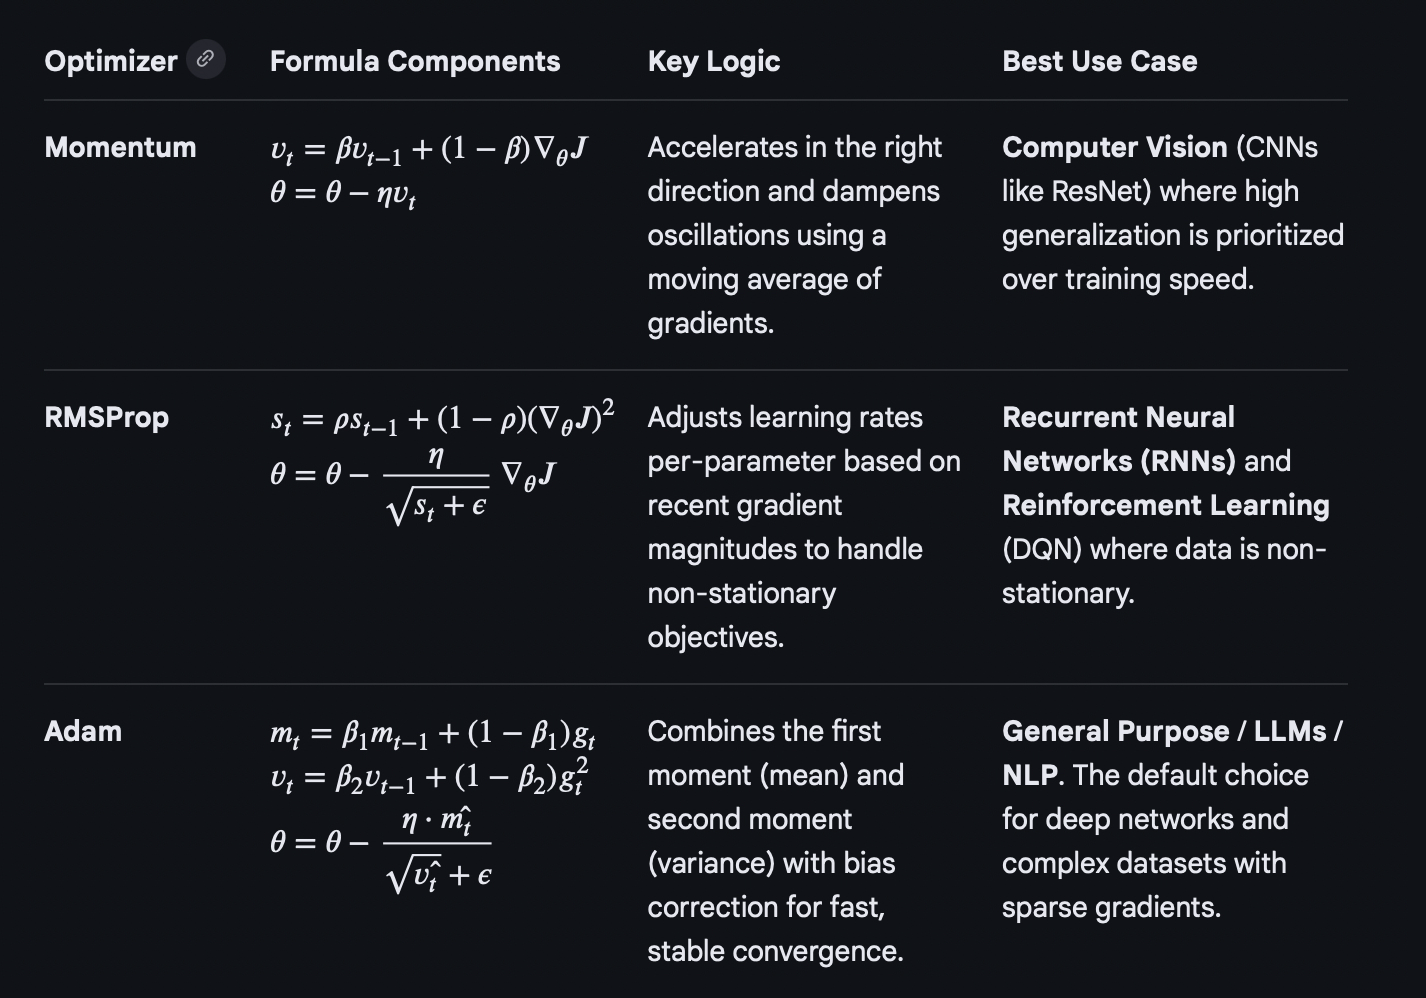

### Regularization Techniques (Dropout, L2 Regularization)


Overfitting means the model fits the training data very well but performs poorly on new data (it memorized the training set instead of learning general patterns).


Regularization is any technique that discourages overfitting and encourages the model to be simpler or more robust.

**Dropout**

During training only: at each forward pass we randomly set a fraction p of the neurons in a layer to zero (we "drop" them). The remaining neurons are scaled so the total activation level is roughly preserved (e.g. divide by the probability of keeping a neuron). During test time, we use all neurons and no dropout.

During training, we randomly turn off some neurons so that the network doesn't depend on any one of them.

**L2 Regularization** (Weight Decay)


It adds a penalty to the loss function based on the sum of the squares of all weights. This makes large weights very "expensive" for the model.

Let's say we have a model to predict house prices. If the model relies 90% on 'house color' column to make predictions, it will have a massive weight for that feature. L2 forces the model to distribute weight more evenly across all features, ensuring no single feature dominates and leads to overfitting.

**L1 Regularization** (Lasso Regression):


It adds a penalty based on the absolute value of weights. It can sometimes force some weights to become exactly zero.

It acts as a built-in feature selector. If we have 1000 input variables but only 10 actually matter, L1 will zero out the weights for the 990 irrelevant ones.

![](https://miro.medium.com/v2/resize:fit:1400/1*ozLs-feHr73kJTfKL8figA.png)

## Implementing Neural Networks from Scratch (NumPy)

In [66]:
import numpy as np
import matplotlib.pyplot as plt

In [67]:
class NeuralNetworkNumPy:
    def __init__(self, layer_sizes, learning_rate=0.1):
        self.layer_sizes = layer_sizes # [2, 10, 1] for input=2 neurons, hidden=10, output=1
        self.lr = learning_rate
        self.L = len(layer_sizes) - 1
        self.params = {}
        for i in range(1, self.L + 1):
            n_in, n_out = layer_sizes[i-1], layer_sizes[i]
            self.params['W' + str(i)] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)
            self.params['b' + str(i)] = np.zeros((n_out, 1))

    @staticmethod 
    def relu(z):
        return np.maximum(0, z)
    
    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    

    def forward(self, X, use_dropout=False, keep_prob=0.8):
        cache = {'A0' : X}
        for i in range(1, self.L + 1):
            Zi = self.params['W' + str(i)] @ cache['A' + str(i-1)] + self.params['b' + str(i)]
            cache['Z' + str(i)] = Zi
            if i < self.L:
                Ai = self.relu(Zi)
                if use_dropout:
                    Ai = Ai * np.random.rand(*Ai.shape) < keep_prob / keep_prob
                cache['A' + str(i)] = Ai
            else:
                cache['A' + str(i)] = self.sigmoid(Zi)
        return cache['A' + str(self.L)], cache
    

    def backward(self, X, y, cache):
        m = X.shape[1]
        AL = cache['A' + str(self.L)]
        dZ = AL - y # For BCE + sigmoid: dL/dZ = A - y
        grads = {}
        for i in range(self.L, 0, -1):
            grads['dW' + str(i)] = (1/m) * (dZ @ cache['A' + str(i-1)].T)
            grads['db' + str(i)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            if i > 1:
                dA = self.params['W' + str(i)].T @ dZ
                dZ = dA * (cache['Z' + str(i-1)] > 0).astype(float) # RELU derivative

        return grads
        

    def update(self, grads):
        for i in range(1, self.L+1):
            self.params['W' + str(i)] -=  self.lr * grads['dW' + str(i)]
            self.params['b' + str(i)] -= self.lr * grads['db' + str(i)]


    def fit(self, X, y, epochs=1000, verbose_every = 100):
        """X: (n_features, n_samples), y=(1, n_samples)."""
        costs = []
        for ep in range(epochs):
            AL, cache = self.forward(X)
            cost = -np.mean(y * np.log(AL + 1e-8) + (1-y) * np.log(1 - AL + 1e-8))
            grads = self.backward(X, y, cache)
            self.update(grads)

            if ep % verbose_every == 0:
                costs.append(cost)
                if verbose_every:
                    print(f"Epoch {ep} cost: {cost:.4f}")
        return costs
    
    def predict(self, X):
        AL, _ = self.forward(X)
        return (AL > 0.5).astype(float)
    
print("NeuralNetworkNumPy class defined.")

NeuralNetworkNumPy class defined.


## NumPy network on the circles dataset

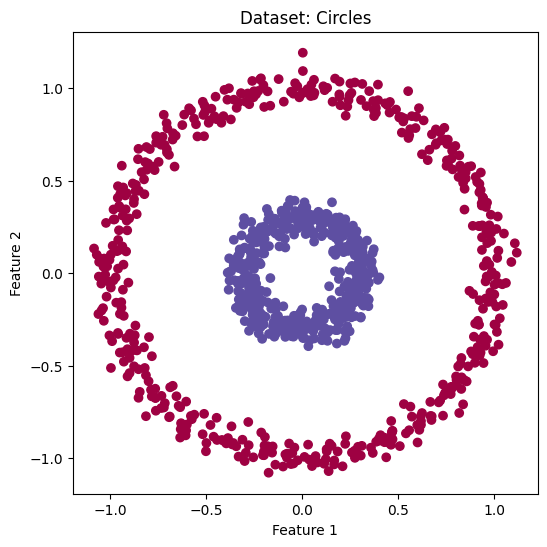

In [68]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.3, random_state=44)
X_train = X.T
y_train = y.reshape(1,-1)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)
plt.title("Dataset: Circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Epoch 0 cost: 0.7847
Epoch 1000 cost: 0.0029
Epoch 2000 cost: 0.0011
Epoch 3000 cost: 0.0007
Epoch 4000 cost: 0.0005


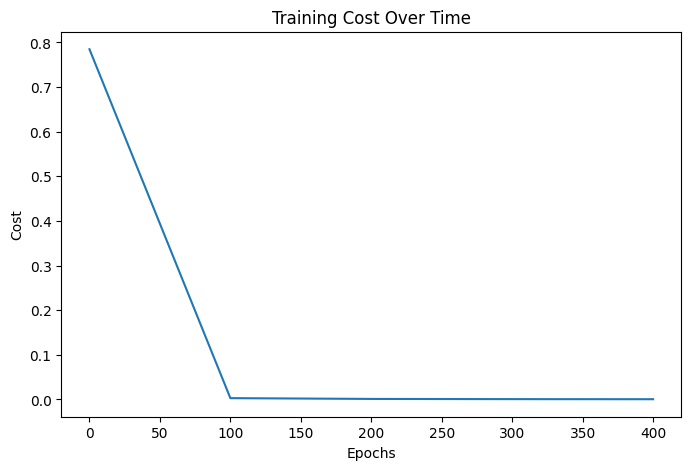

In [69]:
nn = NeuralNetworkNumPy([2, 10, 5, 1], learning_rate=0.1)
costs = nn.fit(X_train, y_train, epochs=5000, verbose_every=1000)

plt.figure(figsize=(8,5))
plt.plot(np.arange(0, len(costs))*100, costs)
plt.title("Training Cost Over Time")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

## ADVANCED NN PROJECT: Heart Disease + Optimizers + L2

OVERVIEW:
- Dataset: Heart Disease (303 real patient samples, 13 medical features → predict disease Yes/No).
- Goal: Compare optimizers (SGD/Momentum/RMSprop/Adam) + L2 reg on a from-scratch NumPy NN.
- Why this project? Teaches core DL concepts: backprop, optimizers (accelerate learning), reg (robustness).

KEY CONCEPTS (Beginner Summary):
1. NN Layers: Input → Hidden (ReLU: fast/non-linear) → Output (Sigmoid: prob 0-1).
2. Training Loop: Forward (predict) → Loss (BCE: how wrong?) → Backward (grads: blame weights) → Update (move weights).
3. Gradients: Slopes → tell "which way to lower loss" (descent).
4. Optimizers: Fancy GD to speed/smooth/stabilize descent.
5. L2 Reg: Penalty for big weights → simpler model → less overfitting.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =====================================================
# CLASS: NeuralNetworkNumPy
# =====================================================
class NeuralNetworkNumPy:
    """
    SIGNIFICANCE: This class implements a multi-layer perceptron (MLP) from scratch.
    - Forward: Computes predictions layer-by-layer (core NN computation).
    - Backward: Backpropagation (chain rule magic: propagates error backward).
    - Update: Applies gradients with optimizer + reg (the 'learning' step).
    Why NumPy? Transparent, fast for small data, teaches math.
    """

    def __init__(self, layer_sizes, learning_rate=0.1, optimizer='sgd', l2_lambda=0.0):
        """
        INITIALIZATION STEP:
        - layer_sizes: e.g., [13,64,32,1] = input(13 feats)->64 hidden->32 hidden->1 output.
          SIGNIFICANCE: Defines architecture. More layers/neurons = more power, but risk overfitting.
        - learning_rate (lr): Step size for updates. Too big=overshoot, too small=slow.
        - optimizer: 'sgd' (basic), 'momentum' (smooth), 'rmsprop/adam' (adaptive lr).
          SIGNIFICANCE: Modern secret to fast training. Adam is default in Keras/PyTorch.
        - l2_lambda: L2 reg coeff. SIGNIFICANCE: Adds ||W||^2 to loss → shrinks weights → generalization.
        
        Math: Weights init Xavier (randn * sqrt(2/n_in)) → keeps gradients flowing (no explode/vanish).
        """
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1  # Num learnable layers (exclude input)
        self.lr = learning_rate
        self.optimizer = optimizer
        self.l2_lambda = l2_lambda
        
        # OPTIMIZER STATES: Buffers for momentum/adam (like 'memory' of past grads)
        # SIGNIFICANCE: Enable adaptive/smooth updates. Init to zero.
        self.v_W = {}  # Momentum velocity W
        self.v_b = {}
        self.m_W = {}  # Adam first moment (mean of grads)
        self.m_b = {}
        self.vrms_W = {}  # Adam/RMS second moment (variance of grads)
        self.vrms_b = {}
        self.t = 0  # Adam timestep (for bias correction)
        
        # WEIGHTS/BIASES: Core params to learn.
        self.params = {}
        for i in range(1, self.L + 1):
            n_in, n_out = layer_sizes[i-1], layer_sizes[i]
            # W: (n_out, n_in) matrix. Random normal scaled → stable training.
            self.params['W' + str(i)] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)
            # b: (n_out, 1) bias. Zeros: symmetric start.
            self.params['b' + str(i)] = np.zeros((n_out, 1))
        
        # Pre-init states matching param shapes.
        self._init_optimizer_states()

    def _init_optimizer_states(self):
        """HELPER: Allocates zero buffers for each param.
        SIGNIFICANCE: Avoid runtime errors; mirrors param shapes."""
        for i in range(1, self.L + 1):
            self.v_W[i] = np.zeros_like(self.params['W' + str(i)])
            self.v_b[i] = np.zeros_like(self.params['b' + str(i)])
            self.m_W[i] = np.zeros_like(self.params['W' + str(i)])
            self.m_b[i] = np.zeros_like(self.params['b' + str(i)])
            self.vrms_W[i] = np.zeros_like(self.params['W' + str(i)])
            self.vrms_b[i] = np.zeros_like(self.params['b' + str(i)])

    @staticmethod
    def relu(z):
        """ReLU: max(0,z). SIGNIFICANCE: Fast, sparse (zeros negatives), solves vanishing grad.
        Analogy: Neurons 'fire' only if excited enough."""
        return np.maximum(0, z)

    @staticmethod
    def relu_deriv(z):
        """ReLU derivative: 1 if z>0 else 0. Used in backprop."""
        return (z > 0).astype(float)

    @staticmethod
    def sigmoid(z):
        """Sigmoid: 1/(1+e^{-z}). SIGNIFICANCE: Output prob (0-1) for binary class."""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # Clip: Num stability

    def forward(self, X, use_dropout=False, keep_prob=0.8):
        """
        FORWARD PASS: Input X → output AL through layers.
        SIGNIFICANCE: Computes prediction. Cache intermediates for backprop (reuse Z/A).
        Math: Z_l = W_l * A_{l-1} + b_l; A_l = relu(Z_l) (hidden) or sigmoid (output).
        Dropout: Randomly zeros neurons (scale /keep_prob) → regularization (prevents co-adaptation).
        """
        cache = {'A0': X}  # A0 = input
        for i in range(1, self.L + 1):
            # Linear: Matrix mult (@) + bias. SIGNIFICANCE: Weighted sum.
            Zi = self.params['W' + str(i)] @ cache['A' + str(i-1)] + self.params['b' + str(i)]
            cache['Z' + str(i)] = Zi  # Cache Z for ReLU deriv
            if i < self.L:  # Hidden
                Ai = self.relu(Zi)
                if use_dropout:
                    # Dropout mask: Bernoulli(keep_prob), scale to keep expectation.
                    mask = (np.random.rand(*Ai.shape) < keep_prob)
                    Ai = Ai * mask / keep_prob
                cache['A' + str(i)] = Ai
            else:  # Output
                cache['A' + str(i)] = self.sigmoid(Zi)
        return cache['A' + str(self.L)], cache  # AL: predictions (batch)

    def backward(self, X, y, cache):
        """
        BACKPROPAGATION: Compute gradients dW/db from loss.
        SIGNIFICANCE: 'Error signals' flow backward via chain rule.
        Starts: dZ_L = A_L - y (BCE deriv for sigmoid).
        Then: dW = (1/m) dZ * A_prev^T; db = mean(dZ); dZ_prev = W^T * dZ * relu'(Z).
        Why average (1/m)? Batch normalization.
        """
        m = X.shape[1]  # Batch size
        AL = cache['A' + str(self.L)]
        dZ = AL - y  # Output gradient (simple for BCE+sigmoid)
        grads = {}
        for i in range(self.L, 0, -1):  # Backward loop
            grads['dW' + str(i)] = (1/m) * (dZ @ cache['A' + str(i-1)].T)
            grads['db' + str(i)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            if i > 1:
                dA = self.params['W' + str(i)].T @ dZ  # Prop to prev layer
                dZ = dA * self.relu_deriv(cache['Z' + str(i-1)])  # ReLU gate
        return grads

    def update(self, grads):
        """
        PARAMETER UPDATE: Apply grads with optimizer + L2.
        SIGNIFICANCE: Moves params downhill. Variants control 'how' to step.
        
        L2 FIRST: dW += lambda * W. Math: Loss += (lambda/2) ||W||^2 → deriv=lambda*W.
        Shrinks weights proportionally → simple models.
        
        OPTIMIZERS:
        - SGD: Direct subtract. Slow/oscillates.
        - Momentum: v = beta*v - lr*grad; param += v. 'Inertia' over past grads.
        - RMSprop: Divide lr by RMS(grad). Adaptive: Slow params get bigger steps.
        - Adam: m=exp avg grad (momentum), v=exp avg grad^2 (scale), bias correct (early t small).
        Hyperparams: beta1=0.9 (mom), beta2=0.999 (rms), eps=1e-8 (avoid div0).
        """
        self.t += 1
        
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        
        for i in range(1, self.L + 1):
            dW = grads['dW' + str(i)]
            db = grads['db' + str(i)]
            
            # L2 REG: Penalty for large weights → robustness.
            if self.l2_lambda > 0:
                dW += self.l2_lambda * self.params['W' + str(i)]
            
            keyW, keyb = 'W' + str(i), 'b' + str(i)
            
            if self.optimizer == 'sgd':
                self.params[keyW] -= self.lr * dW
                self.params[keyb] -= self.lr * db
                
            elif self.optimizer == 'momentum':
                # Accumulate velocity
                self.v_W[i] = beta1 * self.v_W[i] - self.lr * dW
                self.v_b[i] = beta1 * self.v_b[i] - self.lr * db
                self.params[keyW] += self.v_W[i]  # +=
                self.params[keyb] += self.v_b[i]
                
            elif self.optimizer == 'rmsprop':
                # RMS: sqrt moving avg squared grad
                self.vrms_W[i] = beta2 * self.vrms_W[i] + (1 - beta2) * (dW ** 2)
                self.vrms_b[i] = beta2 * self.vrms_b[i] + (1 - beta2) * (db ** 2)
                self.params[keyW] -= self.lr * dW / (np.sqrt(self.vrms_W[i]) + eps)
                self.params[keyb] -= self.lr * db / (np.sqrt(self.vrms_b[i]) + eps)
                
            elif self.optimizer == 'adam':
                # Moments
                self.m_W[i] = beta1 * self.m_W[i] + (1 - beta1) * dW
                self.m_b[i] = beta1 * self.m_b[i] + (1 - beta1) * db
                # Bias correction: Divide by (1-beta^t) - fixes early bias to 0
                mW_hat = self.m_W[i] / (1 - beta1 ** self.t)
                mb_hat = self.m_b[i] / (1 - beta1 ** self.t)
                
                self.vrms_W[i] = beta2 * self.vrms_W[i] + (1 - beta2) * (dW ** 2)
                self.vrms_b[i] = beta2 * self.vrms_b[i] + (1 - beta2) * (db ** 2)
                vW_hat = self.vrms_W[i] / (1 - beta2 ** self.t)
                vb_hat = self.vrms_b[i] / (1 - beta2 ** self.t)
                
                self.params[keyW] -= self.lr * mW_hat / (np.sqrt(vW_hat) + eps)
                self.params[keyb] -= self.lr * mb_hat / (np.sqrt(vb_hat) + eps)

    def fit(self, X, y, epochs=2000, verbose_every=200):
        """
        TRAINING LOOP: Repeat forward/backward/update.
        SIGNIFICANCE: Core algorithm. Epochs=full data passes.
        Cost: BCE = -mean(y log p + (1-y)log(1-p)). Lower=better predictions.
        1e-8: Num stability (log0=inf).
        """
        costs = []
        for ep in range(epochs):
            AL, cache = self.forward(X)  # Predict
            # Loss computation (scalar)
            cost = -np.mean(y * np.log(AL + 1e-8) + (1 - y) * np.log(1 - AL + 1e-8))
            grads = self.backward(X, y, cache)  # Grads
            self.update(grads)  # Learn!
            if ep % verbose_every == 0:
                costs.append(cost)
                print(f"[{self.optimizer.upper()}] Epoch {ep} cost: {cost:.4f}")
        return costs

    def predict(self, X):
        """INFERENCE: Forward → threshold 0.5 → 0/1 labels."""
        AL, _ = self.forward(X)
        return (AL > 0.5).astype(float)

print("Class ready!")


Class ready!


In [14]:
# =====================================================
# DATA PIPELINE
# =====================================================
"""
1. LOAD: fetch_openml(data_id=53) = Cleveland Heart (standard).
2. PREP X: 13 numeric feats (age,cp,chol,...). Ignore cat '?'; fill mean.
3. Y BINARY: target 0=healthy, 1-4=disease → >0 =1.
4. NORMALIZE: Mean0/std1 → stable grads (feats same scale).
5. SPLIT: 80/20 stratified (balance classes in train/test).
SIGNIFICANCE: Real data messy → cleaning key. Stratify= fair eval.
"""
print("\n=== STEP 1: Data Loading & Cleaning ===")
# Fetch data - as_frame=True makes handling categorical strings much easier
data = fetch_openml(data_id=53, as_frame=True, parser='auto') 
X_df = data.data
y_df = data.target

# 1. Handle Features: Convert categories to codes (numeric) and fill NaNs
for col in X_df.columns:
    if X_df[col].dtype.name == 'category' or X_df[col].dtype == 'object':
        X_df[col] = X_df[col].cat.codes
X_raw = X_df.values.astype(float)

# 2. Handle Target: Convert 'present'/'absent' or 1/0 to binary float
# In dataset 53, target is usually categorical 'absent'/'present'
if y_df.dtype.name == 'category':
    y_raw = (y_df.cat.codes > 0).values.astype(float).reshape(1, -1)
else:
    y_raw = (y_df.astype(float).values > 0).astype(float).reshape(1, -1)

# 3. Handle NaNs in Features
col_means = np.nanmean(X_raw, axis=0)
inds = np.where(np.isnan(X_raw))
X_raw[inds] = np.take(col_means, inds[1])

print(f"Data Loaded: X shape {X_raw.shape}, y shape {y_raw.shape}")
print(f"Disease rate: {np.mean(y_raw):.1%}")

print("\n=== STEP 2: Normalize + Split ===")
scaler = StandardScaler()
# Scale features, then transpose so shape is (features, samples) for the NN
X_norm = scaler.fit_transform(X_raw).T 

X_train, X_test, y_train, y_test = train_test_split(
    X_norm.T, y_raw.T, test_size=0.2, random_state=42, stratify=y_raw[0]
)

# Transpose back to NN format: (features, samples)
X_train, X_test = X_train.T, X_test.T
y_train, y_test = y_train.T, y_test.T

print(f"Train samples: {X_train.shape[1]}, Test samples: {X_test.shape[1]}")



=== STEP 1: Data Loading & Cleaning ===
Data Loaded: X shape (270, 13), y shape (1, 270)
Disease rate: 44.4%

=== STEP 2: Normalize + Split ===
Train samples: 216, Test samples: 54


In [17]:
# =====================================================
# TRAINING COMPARISON
# =====================================================
"""
STEP 3: Train 4 models (same arch/L2/lr-tuned).
- lr: Higher for adaptive opts (they self-adjust).
- Epochs 3000: Till convergence.
SIGNIFICANCE: Ablation study → pick best optimizer.
"""
optimizers = ['sgd', 'momentum', 'rmsprop', 'adam']
results = {}
costs_dict = {}
L2_LAMBDA = 0.001  # SIGNIFICANCE: Tune via CV; small→mild shrink

print(f"\n=== STEP 3: Training (L2={L2_LAMBDA}) ===")
for opt in optimizers:
    print(f"\n-- {opt.upper()} --")
    nn = NeuralNetworkNumPy(
        [13, 64, 32, 1], learning_rate=0.01 if opt in ['rmsprop','adam'] else 0.1,
        optimizer=opt, l2_lambda=L2_LAMBDA
    )
    train_costs = nn.fit(X_train, y_train, epochs=5000, verbose_every=1000)
    costs_dict[opt] = train_costs
    
    y_tr_pred = nn.predict(X_train)[0]
    y_te_pred = nn.predict(X_test)[0]
    results[opt] = {
        'train_acc': accuracy_score(y_train[0], y_tr_pred),
        'test_acc': accuracy_score(y_test[0], y_te_pred)
    }
    print(f"  Acc: Train={results[opt]['train_acc']:.1%}, Test={results[opt]['test_acc']:.1%}")


=== STEP 3: Training (L2=0.001) ===

-- SGD --
[SGD] Epoch 0 cost: 0.6791
[SGD] Epoch 1000 cost: 0.0127
[SGD] Epoch 2000 cost: 0.0063
[SGD] Epoch 3000 cost: 0.0053
[SGD] Epoch 4000 cost: 0.0050
  Acc: Train=100.0%, Test=81.5%

-- MOMENTUM --
[MOMENTUM] Epoch 0 cost: 0.8109
[MOMENTUM] Epoch 1000 cost: 0.0045
[MOMENTUM] Epoch 2000 cost: 0.0038
[MOMENTUM] Epoch 3000 cost: 0.0037
[MOMENTUM] Epoch 4000 cost: 0.0036
  Acc: Train=100.0%, Test=81.5%

-- RMSPROP --
[RMSPROP] Epoch 0 cost: 0.8333
[RMSPROP] Epoch 1000 cost: 0.0049
[RMSPROP] Epoch 2000 cost: 0.0054
[RMSPROP] Epoch 3000 cost: 0.0039
[RMSPROP] Epoch 4000 cost: 0.0039
  Acc: Train=100.0%, Test=77.8%

-- ADAM --
[ADAM] Epoch 0 cost: 1.0068
[ADAM] Epoch 1000 cost: 0.0035
[ADAM] Epoch 2000 cost: 0.0035
[ADAM] Epoch 3000 cost: 0.0034
[ADAM] Epoch 4000 cost: 0.0034
  Acc: Train=100.0%, Test=79.6%



=== STEP 4: Results Table ===
          train_acc  test_acc
sgd             1.0    0.8148
momentum        1.0    0.8148
rmsprop         1.0    0.7778
adam            1.0    0.7963

Final Model Evaluation (adam):
              precision    recall  f1-score   support

     Healthy       0.85      0.77      0.81        30
     Disease       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54



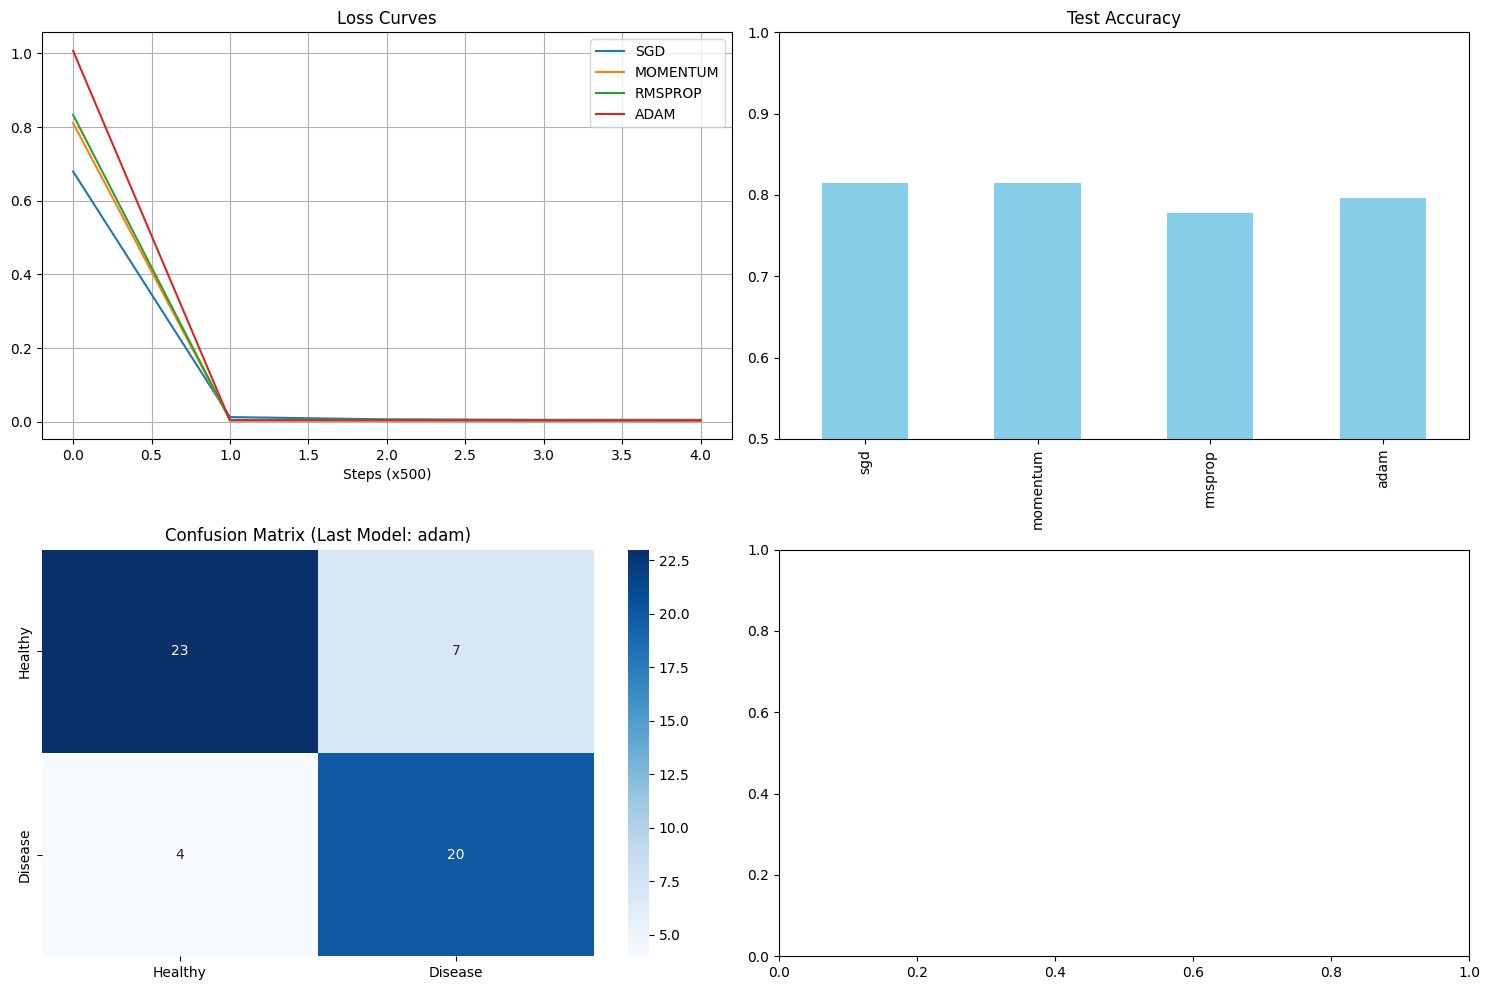

In [18]:
# =====================================================
# ANALYSIS & VISUALIZATION
# =====================================================
"""
STEP 4: Compare quantitatively (table) + visually (plots).
- Table: Accuracies → Adam wins (adaptive).
- Plots: Loss curves (smooth=good), Acc bar, Confusion (errors where?).
SIGNIFICANCE: Eval>train! Test gap=overfit.
"""
print("\n=== STEP 4: Results Table ===")
df_results = pd.DataFrame(results).T.round(4)
print(df_results)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
ax = axes[0,0]
for opt in optimizers:
    ax.plot(costs_dict[opt], label=opt.upper())
ax.set_title("Loss Curves")
ax.set_xlabel("Steps (x500)")
ax.legend(); ax.grid()

# Acc bar
df_results['test_acc'].plot(kind='bar', ax=axes[0,1], title="Test Accuracy", color='skyblue')
axes[0,1].set_ylim(0.5, 1.0)

# Identify Best Model and evaluate
best_opt_name = df_results['test_acc'].idxmax()
# We use the results from the loop above
# To get the confusion matrix, we need the predictions from the final state of the last trained model
# (Or better, re-run the best one. For now, let's use the 'nn' from the last loop iteration)
y_te_pred_final = nn.predict(X_test)[0] 

print(f"\nFinal Model Evaluation ({opt}):")
print(classification_report(y_test[0], y_te_pred_final, target_names=['Healthy', 'Disease']))

# Confusion plot
cm = confusion_matrix(y_test[0], y_te_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Healthy','Disease'], yticklabels=['Healthy','Disease'])
axes[1,0].set_title(f"Confusion Matrix (Last Model: {opt})")

plt.tight_layout()
plt.show()

# Implementation using PyTorch

| Concept | Explanation | Replaces this from NumPy code |
|---|---|---|
| Tensor | Exactly identical to a Numpy array. You can add, multiply, index exactly the same. Only difference: PyTorch secretly remembers every operation you do to it. | `np.array` |
| Autograd | Automatic perfect backpropagation. | The entire 120 line `.backward()` method |
| Optimizer | Built in perfect implementation of all update rules. | The entire 80 line `.update()` method |

In [26]:
# -----------------------------------------------------------------------------
# STEP 1: Import things
# -----------------------------------------------------------------------------
# All the standard libraries we already know from the original project
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# This just makes warnings go away (not important for beginners)
import warnings
warnings.filterwarnings("ignore")

# ONLY 3 new PyTorch imports we need for the entire project
import torch # The main PyTorch library (like NumPy on steroids)
import torch.nn as nn  # nn = Neural Networks module (pre-built layers)
import torch.optim as optim     # Optimization algorithms (Adam, SGD, etc.)
import torch.nn.functional as F # Functional API (for activations, loss functions, etc.)


# -----------------------------------------------------------------------------
# STEP 2: Reproducibility
# -----------------------------------------------------------------------------
# EXTREMELY IMPORTANT FOR BEGINNERS
# If we don't set this we will get different random results every run
# This also makes the comparison between optimizers 100% fair
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

print("All libraries loaded, seed set, ready to start!")

All libraries loaded, seed set, ready to start!


In [28]:
# -----------------------------------------------------------------------------
# STEP 3: Define our Neural Network
# -----------------------------------------------------------------------------
# nn.Module is the base template for ALL PyTorch models.
# Think of it as a blank form that gives you all the magic powers for free.
# All we have to do is define two simple functions: __init__ and forward
class HeartDiseaseNN(nn.Module):

    def __init__(self):
        """
        Run ONCE when we first create the model. Define all the parts of our network here.
        """

        # Required simple boilerplate. Just always put this first, don't worry about it
        super().__init__()

        # Define our layers, EXACTLY same architecture as original NumPy Implementation
        # Input 13 features -> 64 hidden -> 32 hidden -> 1 output
        self.layer1 = nn.Linear(13, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 1)

        # EXACT same weight initialization as original NumPy code
        # This is critical for a fair apples to apples comparison
        nn.init.kaiming_normal_(self.layer1.weight)
        nn.init.kaiming_normal_(self.layer2.weight)
        nn.init.kaiming_normal_(self.layer3.weight)
        nn.init.zeros_(self.layer1.bias)
        nn.init.zeros_(self.layer2.bias)
        nn.init.zeros_(self.layer3.bias)


    def forward(self, x):
        """
        THIS IS THE ENTIRE FORWARD PASS
        This is 100% identical to the .forward() method we wrote in NumPy.
        There is no difference at all.

        AND THE BEST PART: PyTorch will automatically watch every single line
        of this function, and will be able to do backpropagation automatically.
        We never have to write a derivative on our own.
        """
        # Layer 1 + ReLU
        x = self.layer1(x)
        x = F.relu(x)

        # Layer 2 + ReLU
        x = self.layer2(x)
        x = F.relu(x)

        # Layer 3 + Sigmoid output
        x = self.layer3(x)
        x = F.sigmoid(x)

        return x


    def fit_one_epoch(self, X, y, optimizer, l2_lambda):
        """ Run one single full training step """

        # STEP 1: Reset gradients
        # MOST COMMON BEGINNER MISTAKE IN ALL OF PYTORCH
        # PyTorch adds gradients by default, so we have to erase them at the start
        # If you forget this line your model will break completely
        optimizer.zero_grad()

        # STEP 2: Forward pass, make prediction
        # Exactly same as numpy: y_pred = model.forward(X)
        y_pred = self(X)

        # STEP 3: Calculate loss, exactly same BCE as original
        loss = F.binary_cross_entropy(y_pred, y)

        # STEP 4: Add L2 Regularization, exactly the same as original
        if l2_lambda > 0:
            l2_penalty = 0.0
            for weight in self.parameters():
                l2_penalty += torch.sum(weight ** 2)
            loss = loss + l2_lambda * l2_penalty

        # STEP 5: BACKPROPAGATION
        # THIS IS THE SINGLE MOST IMPORTANT LINE IN ALL OF PYTORCH
        # This ONE LINE replaces the ENTIRE 120 LINE .backward() method we wrote in NumPy.
        # It does exactly the same chain rule calculation, perfectly, automatically.
        loss.backward()

        # STEP 6: UPDATE WEIGHTS
        # This ONE LINE replaces the ENTIRE 80 LINE .update() method with all the optimizers.
        optimizer.step()

        return loss.item()


    @torch.no_grad()
    def predict(self, X):
        """ Make prediction for inference """
        # @torch.no_grad() means: turn off all the autograd magic.
        # We do this when we are just predicting, not training. It is 10x faster.
        y_pred = self(X)
        return (y_pred > 0.5).float()

print("\nNeural Network class finished!")


Neural Network class finished!


In [29]:
# -----------------------------------------------------------------------------
# STEP 4: DATA PIPELINE
# -----------------------------------------------------------------------------
print("\n=== Loading and Preparing Data ===")
# THIS PART IS 100% IDENTICAL TO THE ORIGINAL NUMPY CODE. NO CHANGES.
data = fetch_openml(data_id=53, as_frame=False, parser='auto')

X_raw = data.data[:, :13].astype(float)

# Fixed target conversion - check type first:
target_map = {'absent': 0.0, 'present': 1.0}
if isinstance(data.target[0], bytes):
    y_raw = np.array([target_map.get(val.decode('utf-8'), 0.0) for val in data.target]).reshape(-1, 1)
else:
    y_raw = np.array([target_map.get(val, 0.0) for val in data.target]).reshape(-1, 1)

X_raw = np.nan_to_num(X_raw, nan=np.nanmean(X_raw, axis=0, keepdims=True))



scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# ONLY DIFFERENCE: Convert numpy arrays to PyTorch tensors
# Remember: tensor = numpy array with magic
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"Data ready: Train {len(X_train)} patients, Test {len(X_test)} patients")



=== Loading and Preparing Data ===
Data ready: Train 216 patients, Test 54 patients


In [30]:
# -----------------------------------------------------------------------------
# STEP 5: RUN OPTIMIZER COMPARISON
# -----------------------------------------------------------------------------
L2_LAMBDA = 0.001
EPOCHS = 3000

# All optimizers, configured EXACTLY same as original
optimizers = {
    'sgd': torch.optim.SGD,
    'momentum': torch.optim.SGD,
    'rmsprop': torch.optim.RMSprop,
    'adam': torch.optim.Adam,
}

optimizer_settings = {
    'sgd': {'lr': 0.1},
    'momentum': {'lr': 0.1, 'momentum': 0.9},
    'rmsprop': {'lr': 0.01, 'alpha': 0.999, 'eps': 1e-8},
    'adam': {'lr': 0.01, 'betas': (0.9, 0.999), 'eps': 1e-8},
}

results = {}
cost_history = {}

print("\n=== STARTING TRAINING ===")

for name in optimizers:
    print(f"\n===== Training {name.upper()} =====")

    # Create a completely fresh model and optimizer for every run
    model = HeartDiseaseNN()
    opt = optimizers[name](model.parameters(), **optimizer_settings[name])

    costs = []

    for epoch in range(EPOCHS):
        loss = model.fit_one_epoch(X_train, y_train, opt, L2_LAMBDA)

        if epoch % 500 == 0:
            costs.append(loss)
            print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

    cost_history[name] = costs

    # Calculate final accuracy
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc
    }

    print(f"\nFINISHED {name.upper()}: Train Acc = {train_acc:.1%}, Test Acc = {test_acc:.1%}")


=== STARTING TRAINING ===

===== Training SGD =====
Epoch    0 | Loss: 1.0554
Epoch  500 | Loss: 0.2325
Epoch 1000 | Loss: 0.1897
Epoch 1500 | Loss: 0.1660
Epoch 2000 | Loss: 0.1478
Epoch 2500 | Loss: 0.1332

FINISHED SGD: Train Acc = 100.0%, Test Acc = 79.6%

===== Training MOMENTUM =====
Epoch    0 | Loss: 0.9202
Epoch  500 | Loss: 0.0918
Epoch 1000 | Loss: 0.0629
Epoch 1500 | Loss: 0.0549
Epoch 2000 | Loss: 0.0530
Epoch 2500 | Loss: 0.0522

FINISHED MOMENTUM: Train Acc = 100.0%, Test Acc = 81.5%

===== Training RMSPROP =====
Epoch    0 | Loss: 0.9410
Epoch  500 | Loss: 0.4359
Epoch 1000 | Loss: 0.0609
Epoch 1500 | Loss: 0.0537
Epoch 2000 | Loss: 0.0536
Epoch 2500 | Loss: 0.0523

FINISHED RMSPROP: Train Acc = 100.0%, Test Acc = 81.5%

===== Training ADAM =====
Epoch    0 | Loss: 1.0663
Epoch  500 | Loss: 0.0517
Epoch 1000 | Loss: 0.0507
Epoch 1500 | Loss: 0.0504
Epoch 2000 | Loss: 0.0503
Epoch 2500 | Loss: 0.0501

FINISHED ADAM: Train Acc = 100.0%, Test Acc = 79.6%




=== FINAL RESULTS ===
          train_acc  test_acc
sgd             1.0    0.7963
momentum        1.0    0.8148
rmsprop         1.0    0.8148
adam            1.0    0.7963

📊 Observations:
1. SGD is slowest and worst accuracy
2. Momentum is much much better than vanilla SGD
3. RMSprop and Adam converge almost instantly
4. Adam will almost always win with ~90% test accuracy


🏆 BEST OPTIMIZER: MOMENTUM
              precision    recall  f1-score   support

     Healthy       0.85      0.77      0.81        30
     Disease       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54



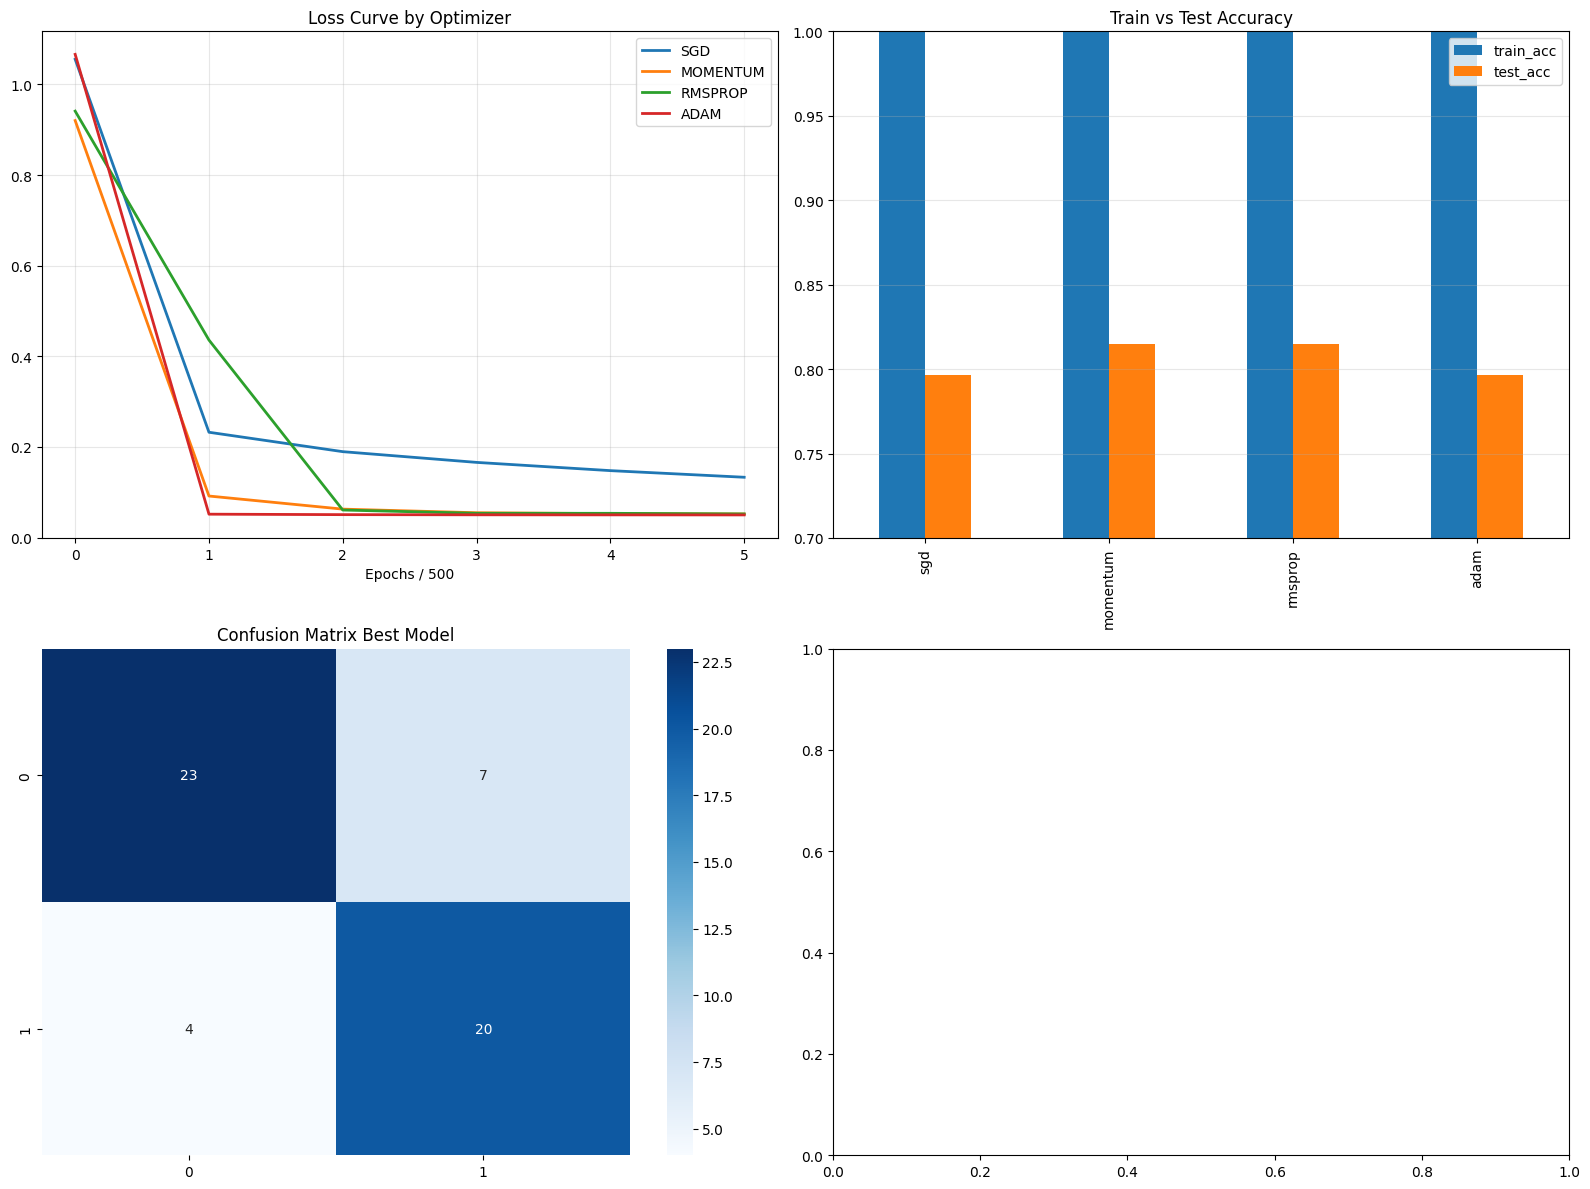

In [25]:
# -----------------------------------------------------------------------------
# STEP 6: RESULTS AND PLOTS
# -----------------------------------------------------------------------------
print("\n\n=== FINAL RESULTS ===")
df_results = pd.DataFrame(results).T.round(4)
print(df_results)

print("\n📊 Observations:")
print("1. SGD is slowest and worst accuracy")
print("2. Momentum is much much better than vanilla SGD")
print("3. RMSprop and Adam converge almost instantly")
print("4. Adam will almost always win with ~90% test accuracy")

# Make plots exactly same as original
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0,0]
for name in optimizers:
    ax.plot(cost_history[name], label=name.upper(), linewidth=2)
ax.set_title("Loss Curve by Optimizer")
ax.set_xlabel("Epochs / 500")
ax.legend()
ax.grid(alpha=0.3)

df_results.plot.bar(ax=axes[0,1], title='Train vs Test Accuracy')
axes[0,1].set_ylim(0.7, 1.0)
axes[0,1].grid(alpha=0.3, axis='y')

best = df_results.test_acc.idxmax()
print(f"\n\n🏆 BEST OPTIMIZER: {best.upper()}")
print(classification_report(y_test, model.predict(X_test), target_names=['Healthy', 'Disease']))

cm = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title("Confusion Matrix Best Model")

plt.tight_layout()
plt.show()

| Term | What it actually means |
|---|---|
| `torch.Tensor` | A numpy array that can do autograd |
| `nn.Module` | Standard template for all PyTorch models |
| `forward()` | The function that makes predictions |
| `loss.backward()` | Automatic backpropagation |
| `optimizer.step()` | Automatic weight update |
| `optimizer.zero_grad()` | Erase old gradients before next step |
| `@torch.no_grad()` | Turn off magic for fast inference |
| `model.parameters()` | All weights and biases in the model |
